<a href="https://colab.research.google.com/github/aishrad2/CompanyGame/blob/main/Assignment1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#setup
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode

def take_photo(filename='photo.jpg', quality=0.8):
  js = Javascript('''
    async function takePhoto(quality) {
      const div = document.createElement('div');
      const capture = document.createElement('button');
      capture.textContent = 'Capture';
      div.appendChild(capture);

      const video = document.createElement('video');
      video.style.display = 'block';
      const stream = await navigator.mediaDevices.getUserMedia({video: true});

      document.body.appendChild(div);
      div.appendChild(video);
      video.srcObject = stream;
      await video.play();

      // Resize the output to fit the video element.
      google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);

      // Wait for Capture to be clicked.
      await new Promise((resolve) => capture.onclick = resolve);

      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;
      canvas.getContext('2d').drawImage(video, 0, 0);
      stream.getVideoTracks()[0].stop();
      div.remove();
      return canvas.toDataURL('image/jpeg', quality);
    }
    ''')
  display(js)
  data = eval_js('takePhoto({})'.format(quality))
  binary = b64decode(data.split(',')[1])
  with open(filename, 'wb') as f:
    f.write(binary)
  return filename

<IPython.core.display.Javascript object>

Saved to photo.jpg


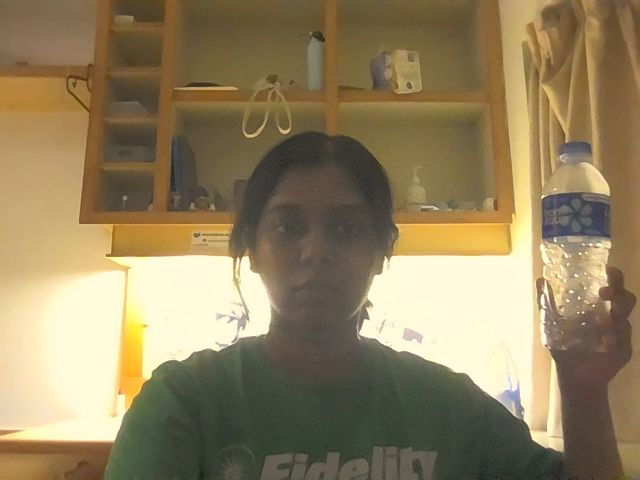

In [ ]:
#task 1
from IPython.display import Image
try:
  filename = take_photo()
  print('Saved to {}'.format(filename))

  # Show the image which was just taken.
  display(Image(filename))
except Exception as err:
  # Errors will be thrown if the user does not have a webcam or if they do not
  # grant the page permission to access it.
  print(str(err))

Lego Grid Dimensions: 100 x 75 


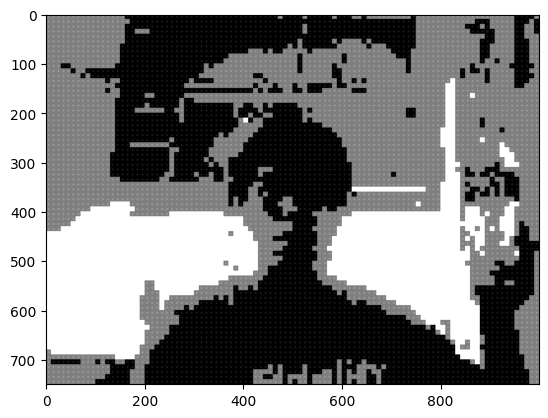

In [ ]:
#task 2
import cv2
import matplotlib.pyplot as plt
import numpy as np


# load the image using opencv into an array
img = cv2.cvtColor(cv2.imread(filename), cv2.COLOR_BGR2RGB)
im = np.array(img)

# use interpolation to resize the image to fit a 100x100 array but keep the proportion of image w and h
small_dimension = 100
h, w, _ = im.shape
if w > h:
    new_w = small_dimension
    new_h = int(h * (100 / w))
else:
    new_h = small_dimension
    new_w = int(w * (100 / h))

small_array = cv2.resize(im, (new_w, new_h), interpolation=cv2.INTER_NEAREST)

# convert the image array into gray
gray_small_array = cv2.cvtColor(small_array, cv2.COLOR_BGR2GRAY)

# use quantization to ensure the image only has 3 colors, preset ranges Black (0-85), Gray (86-170), White (171-255)
for i in range(0, new_h):
  for j in range(0, new_w):
    px = gray_small_array[i,j]
    if (px <= 85):
      gray_small_array[i,j] = 0
    elif (px <= 170):
      gray_small_array[i,j] = 127
    else:
      gray_small_array[i,j] = 255

# resizing blocks for creating lego circles
resizeFactor = 10
gray_big_array = cv2.resize(gray_small_array, (new_w * resizeFactor, new_h * resizeFactor), interpolation=cv2.INTER_NEAREST)
for i in range(new_h):
    for j in range(new_w):
      center_x = (j * resizeFactor) + (resizeFactor // 2)
      center_y = (i * resizeFactor) + (resizeFactor // 2)
      brick_color = int(gray_small_array[i, j])
      stud_color = min(brick_color + 30, 255)
      cv2.circle(gray_big_array, (center_x, center_y), radius=2, color=stud_color, thickness=-1)

#display the image array in gray
plt.imshow(gray_big_array, cmap='gray')
# Print the grid dimensions and total brick count
print(f"Lego Grid Dimensions: {new_w} x {new_h} ")

Total Bricks: 2523
1x1 Bricks: 698 | 1x2 Bricks: 249 | 2x2 Bricks: 1576
Total px: 7500


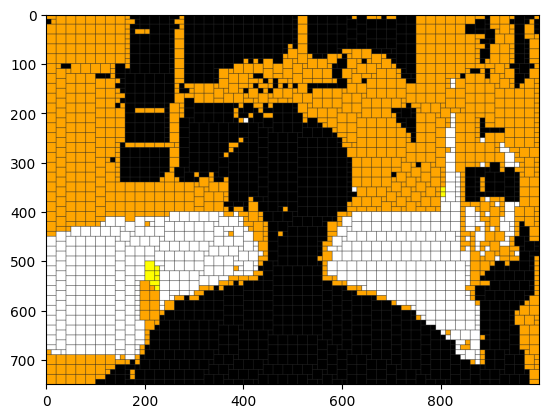

In [ ]:
#task 3
import cv2
import matplotlib.pyplot as plt
import numpy as np

lego_palette = [
    (255, 0, 0), #red
    (255, 165, 0), #orange
    (255, 255, 0), #yellow
    (0, 255, 0), #green
    (0, 0, 255), #blue
    (0, 0, 0), #black
    (255, 255, 255) #white
]

x1x1Bricks = 0
x1x2Bricks = 0
x2x2Bricks = 0

# function to get the closest color to the pixel
def get_closest_color(pixel, palette):
    distances = []
    for color in palette:
        # Euclidean distance between the pixel and the color
        d = np.sum((np.array(pixel) - np.array(color))**2)
        distances.append(d)
    return palette[np.argmin(distances)]

#creating copy of original image resized to 100 x 100
small_color_array = cv2.resize(im, (new_w, new_h), interpolation=cv2.INTER_NEAREST)

# convert the image array into a bricks using only the lego palette
for i in range(new_h):
  for j in range(new_w):
    curr_px = small_color_array[i, j]
    small_color_array[i, j] = get_closest_color(curr_px, lego_palette)

# resizing blocks for creating lego circles
big_color_array = np.zeros((new_h * resizeFactor, new_w * resizeFactor, 3), dtype=np.uint8 )
used_pixels = np.zeros((new_h, new_w), dtype=bool)

for i in range(new_h):
    for j in range(new_w):
      if used_pixels[i, j]:
            continue
      # current color
      color = tuple(map(int, small_color_array[i, j]))
      x1, y1 = j * resizeFactor, i * resizeFactor

      # 2x2 brick
      if (i + 1 < new_h and j + 1 < new_w):
        block = small_color_array[i:i+2, j:j+2]
        block_used = used_pixels[i:i+2, j:j+2]

        if np.all(np.all(block == small_color_array[i, j], axis=2)) and not np.any(block_used):
           used_pixels[i:i+2, j:j+2] = True
           x2, y2 = (j + 2) * resizeFactor, (i + 2) * resizeFactor
           cv2.rectangle(big_color_array, (x1, y1), (x2, y2), color, -1)
           cv2.rectangle(big_color_array, (x1, y1), (x2, y2), (40,40,40), 1)
           x2x2Bricks+=1
           continue

      # 1x2 brick
      if (j + 1 < new_w):
        if np.array_equal(small_color_array[i, j], small_color_array[i, j+1]) and not used_pixels[i, j+1]:
           used_pixels[i, j] = True
           used_pixels[i, j+1] = True
           x2, y2 = (j + 2) * resizeFactor, (i + 1) * resizeFactor
           cv2.rectangle(big_color_array, (x1, y1), (x2, y2), color, -1)
           cv2.rectangle(big_color_array, (x1, y1), (x2, y2), (40,40,40), 1)
           x1x2Bricks+=1
           continue

      # 1x1 brick
      used_pixels[i, j] = True
      x2, y2 = (j + 1) * resizeFactor, (i + 1) * resizeFactor
      cv2.rectangle(big_color_array, (x1, y1), (x2, y2), color, -1)
      cv2.rectangle(big_color_array, (x1, y1), (x2, y2), (40,40,40), 1)
      x1x1Bricks+=1

# print brick summary
totalBricks = x1x1Bricks + x1x2Bricks + x2x2Bricks
print(f"Total Bricks: {totalBricks}")
print(f"1x1 Bricks: {x1x1Bricks} | 1x2 Bricks: {x1x2Bricks} | 2x2 Bricks: {x2x2Bricks}")
check = x1x1Bricks+2*x1x2Bricks+4*x2x2Bricks
print(f"Total px: {check}")
# display the image array with color palette
plt.imshow(big_color_array)
